# Gaze Speed Distribution by Task

This notebook loads `gaze.json`, `labels.npy`, and `segments.json` from `dataset/`, computes frame-aligned angular gaze speed in `deg/s`, and visualizes:
- task-wise gaze speed histograms inside labeled frames (`labels == 1`)
- ordered-label segment-duration histograms for the multi-segment tasks

Ordered labels are defined by segment order in time:
- first labeled segment -> `label 1`
- second labeled segment -> `label 2`

For `single_object_pick_place` and `double_object_pickup`, the duration plots below mean segment length in seconds, for example `0.4s`, `1.2s`, `2.0s`.


In [26]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import savgol_filter

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

DATASET_DIR = Path("dataset")
DEFAULT_FPS = 15.0

TASK_CONFIGS = {
    "Single Object Pickup": "2f_store_dongjun_setup_single_object_pickup",
    "Single Object Pick Place": "2f_store_juheon_setup_single_object_pick_place",
    "Double Object Pickup": "2f_store_juheon_setup_double_object_pickup",
}

TASK_COLORS = {
    "Single Object Pickup": "#1f77b4",
    "Single Object Pick Place": "#ff7f0e",
    "Double Object Pickup": "#2ca02c",
}

ORDERED_LABEL_COLORS = {
    1: "#2563eb",
    2: "#dc2626",
}

TASK_ORDER = list(TASK_CONFIGS.keys())
MULTI_SEGMENT_TASKS = [
    "Single Object Pick Place",
    "Double Object Pickup",
]


In [27]:
def compute_angular_velocity(pitch_yaw: np.ndarray, fps: float, savgol_window: int = 11, savgol_poly: int = 2) -> np.ndarray:
    """Compute frame-aligned gaze angular velocity in deg/s.

    This follows the same definition used in `data_loader.py`.
    """
    pitch = pitch_yaw[:, 0]
    yaw = pitch_yaw[:, 3]

    total_frames = len(pitch)
    if total_frames <= 1 or fps <= 0:
        return np.zeros(total_frames, dtype=np.float64)

    if total_frames < savgol_window:
        savgol_window = total_frames if total_frames % 2 == 1 else total_frames - 1
    savgol_window = max(savgol_window, 3)

    if savgol_poly >= savgol_window:
        savgol_poly = savgol_window - 1

    pitch_s = savgol_filter(pitch, savgol_window, savgol_poly)
    yaw_s = savgol_filter(yaw, savgol_window, savgol_poly)

    x = np.cos(pitch_s) * np.cos(yaw_s)
    y = np.cos(pitch_s) * np.sin(yaw_s)
    z = np.sin(pitch_s)

    step_dot = np.clip(
        x[:-1] * x[1:] + y[:-1] * y[1:] + z[:-1] * z[1:],
        -1.0,
        1.0,
    )
    step_velocity = np.arccos(step_dot) * fps

    angular_velocity = np.zeros(total_frames, dtype=np.float64)
    angular_velocity[0] = step_velocity[0]
    angular_velocity[-1] = step_velocity[-1]

    if total_frames > 2:
        center_dot = np.clip(
            x[:-2] * x[2:] + y[:-2] * y[2:] + z[:-2] * z[2:],
            -1.0,
            1.0,
        )
        angular_velocity[1:-1] = np.arccos(center_dot) * (fps / 2.0)

    return np.rad2deg(angular_velocity)


def discover_episodes(dataset_dir: Path, prefix: str) -> list[Path]:
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    numbered = []

    for path in dataset_dir.iterdir():
        if not path.is_dir():
            continue
        match = pattern.match(path.name)
        if match and (path / "labels.npy").exists() and (path / "gaze.json").exists():
            numbered.append((int(match.group(1)), path))

    numbered.sort(key=lambda item: item[0])
    episodes = [path for _, path in numbered]

    exact = dataset_dir / prefix
    if exact.is_dir() and (exact / "labels.npy").exists() and (exact / "gaze.json").exists():
        episodes = [exact] + episodes

    return episodes


def extract_segments(frame_indices: np.ndarray) -> list[tuple[int, int]]:
    if len(frame_indices) == 0:
        return []

    frame_indices = [int(idx) for idx in frame_indices]
    segments = []
    start = frame_indices[0]
    prev = frame_indices[0]

    for current in frame_indices[1:]:
        if current != prev + 1:
            segments.append((start, prev))
            start = current
        prev = current

    segments.append((start, prev))
    return segments


def load_ordered_segments(episode_dir: Path, labels: np.ndarray) -> list[tuple[int, int]]:
    segments_path = episode_dir / "segments.json"
    if segments_path.exists():
        payload = json.loads(segments_path.read_text())
        raw_segments = payload.get("segments", []) if isinstance(payload, dict) else payload
        ordered_segments = []
        for segment in raw_segments:
            if not isinstance(segment, dict):
                continue
            if "start" not in segment or "end" not in segment:
                continue
            ordered_segments.append((int(segment["start"]), int(segment["end"])))
        ordered_segments.sort(key=lambda item: item[0])
        if ordered_segments:
            return ordered_segments

    positive_frames = np.flatnonzero(labels > 0)
    return extract_segments(positive_frames)


def load_episode_table(episode_dir: Path, task_label: str, task_prefix: str, default_fps: float = DEFAULT_FPS) -> pd.DataFrame:
    labels = np.load(episode_dir / "labels.npy").astype(np.int8)
    gaze_payload = json.loads((episode_dir / "gaze.json").read_text())
    frames = gaze_payload["frames"]

    if len(frames) != len(labels):
        raise ValueError(
            f"Length mismatch for {episode_dir.name}: gaze={len(frames)} labels={len(labels)}"
        )

    fps = default_fps
    ann_path = episode_dir / "annotations.json"
    if ann_path.exists():
        ann_payload = json.loads(ann_path.read_text())
        fps = float(ann_payload.get("fps") or fps)

    pitch_yaw = np.array(
        [
            [
                frame["pitch"],
                frame["pitch_lower"],
                frame["pitch_upper"],
                frame["yaw"],
                frame["yaw_lower"],
                frame["yaw_upper"],
            ]
            for frame in frames
        ],
        dtype=np.float64,
    )

    angular_speed_deg_s = compute_angular_velocity(pitch_yaw, fps=fps)
    ordered_segments = load_ordered_segments(episode_dir, labels)
    ordered_label_id = np.zeros(len(labels), dtype=np.int8)

    for label_id, (start, end) in enumerate(ordered_segments, start=1):
        ordered_label_id[start : end + 1] = label_id

    return pd.DataFrame(
        {
            "task": task_label,
            "task_prefix": task_prefix,
            "episode": episode_dir.name,
            "frame_idx": [int(frame["frame_idx"]) for frame in frames],
            "time_sec": np.arange(len(frames), dtype=np.float64) / fps,
            "fps": fps,
            "label": labels,
            "ordered_label_id": ordered_label_id,
            "angular_speed_deg_s": angular_speed_deg_s,
            "gaze_x": [float(frame["gaze_x"]) for frame in frames],
            "gaze_y": [float(frame["gaze_y"]) for frame in frames],
            "pitch": pitch_yaw[:, 0],
            "yaw": pitch_yaw[:, 3],
        }
    )


In [28]:
all_frames = []
episode_rows = []
segment_rows = []

for task_label, task_prefix in TASK_CONFIGS.items():
    episode_dirs = discover_episodes(DATASET_DIR, task_prefix)
    if not episode_dirs:
        raise FileNotFoundError(f"No episodes found for prefix: {task_prefix}")

    for episode_dir in episode_dirs:
        episode_df = load_episode_table(episode_dir, task_label, task_prefix)
        all_frames.append(episode_df)

        fps = float(episode_df["fps"].iloc[0])
        ordered_counts = episode_df.loc[episode_df["ordered_label_id"] > 0, "ordered_label_id"].value_counts()
        episode_rows.append(
            {
                "task": task_label,
                "episode": episode_dir.name,
                "frames": len(episode_df),
                "labeled_frames": int((episode_df["label"] > 0).sum()),
                "label_ratio": float((episode_df["label"] > 0).mean()),
                "ordered_segment_count": int(episode_df["ordered_label_id"].max()),
                "label_1_frames": int(ordered_counts.get(1, 0)),
                "label_2_frames": int(ordered_counts.get(2, 0)),
                "fps": fps,
            }
        )

        for ordered_label_id in sorted(episode_df["ordered_label_id"].unique()):
            if ordered_label_id == 0:
                continue

            frame_indices = episode_df.loc[
                episode_df["ordered_label_id"] == ordered_label_id,
                "frame_idx",
            ].to_numpy()

            for start_frame, end_frame in extract_segments(frame_indices):
                segment_rows.append(
                    {
                        "task": task_label,
                        "episode": episode_dir.name,
                        "ordered_label_id": int(ordered_label_id),
                        "start_frame": int(start_frame),
                        "end_frame": int(end_frame),
                        "start_sec": start_frame / fps,
                        "end_sec": end_frame / fps,
                        "duration_frames": int(end_frame - start_frame + 1),
                        "duration_sec": (end_frame - start_frame + 1) / fps,
                    }
                )

frames_df = pd.concat(all_frames, ignore_index=True)
frames_df["label_name"] = np.where(frames_df["label"] == 1, "labeled", "background")
episodes_df = pd.DataFrame(episode_rows)
segment_df = pd.DataFrame(segment_rows)

task_summary = (
    episodes_df.groupby("task", sort=False)
    .agg(
        episodes=("episode", "nunique"),
        total_frames=("frames", "sum"),
        labeled_frames=("labeled_frames", "sum"),
        mean_label_ratio=("label_ratio", "mean"),
        avg_ordered_segments=("ordered_segment_count", "mean"),
        fps_values=("fps", lambda series: ", ".join(sorted({f"{value:g}" for value in series}))),
    )
    .round(4)
)

display(task_summary)
display(episodes_df.head())

multi_segment_summary = (
    segment_df[segment_df["task"].isin(MULTI_SEGMENT_TASKS)]
    .groupby(["task", "ordered_label_id"], sort=False)
    .size()
    .rename("segments")
    .reset_index()
)
display(multi_segment_summary)


,episodes,total_frames,labeled_frames,mean_label_ratio,avg_ordered_segments,fps_values
task,,,,,,
Single Object Pickup,79,9135,849,0.1004,1.0000,15
Single Object Pick Place,49,5757,783,0.1379,1.9796,15
Double Object Pickup,73,8890,1371,0.1528,1.9863,15


,task,episode,frames,labeled_frames,label_ratio,ordered_segment_count,label_1_frames,label_2_frames,fps
0,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_1,211,4,0.018957,1,4,0,15.0
1,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_2,137,3,0.021898,1,3,0,15.0
2,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_3,106,15,0.141509,1,15,0,15.0
3,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_4,122,11,0.090164,1,11,0,15.0
4,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_5,115,12,0.104348,1,12,0,15.0


,task,ordered_label_id,segments
0,Single Object Pick Place,1,49
1,Single Object Pick Place,2,48
2,Double Object Pickup,1,73
3,Double Object Pickup,2,72


In [29]:
labeled_df = frames_df[frames_df["label"] == 1].copy()

task_speed_stats = (
    labeled_df.groupby("task", sort=False)["angular_speed_deg_s"]
    .agg(
        samples="count",
        mean="mean",
        median="median",
        std="std",
        p90=lambda series: series.quantile(0.90),
        p95=lambda series: series.quantile(0.95),
        max="max",
    )
    .round(2)
)

display(task_speed_stats)


,samples,mean,median,std,p90,p95,max
task,,,,,,,
Single Object Pickup,849,14.35,9.59,15.08,32.56,46.59,114.72
Single Object Pick Place,783,14.21,10.58,13.18,28.18,43.56,87.44
Double Object Pickup,1371,12.14,7.79,12.03,28.71,39.99,76.09


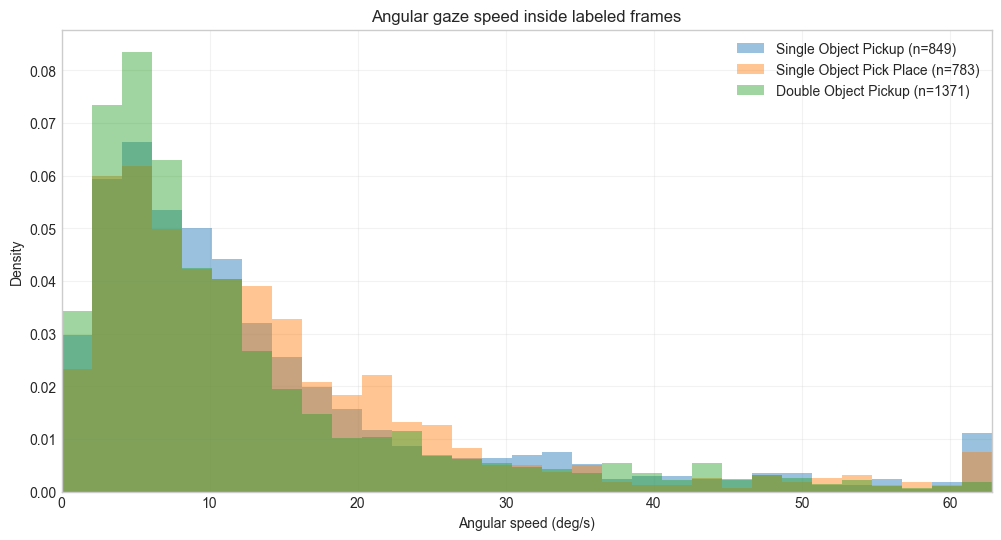

Histogram upper bound is clipped at the global 99th percentile: 62.79 deg/s


In [30]:
hist_max = float(labeled_df["angular_speed_deg_s"].quantile(0.99))
bins = np.linspace(0.0, hist_max, 32)

fig, ax = plt.subplots(figsize=(12, 6))
for task_label in TASK_ORDER:
    task_values = labeled_df.loc[
        labeled_df["task"] == task_label,
        "angular_speed_deg_s",
    ].clip(upper=hist_max)
    ax.hist(
        task_values,
        bins=bins,
        density=True,
        alpha=0.45,
        label=f"{task_label} (n={len(task_values)})",
        color=TASK_COLORS[task_label],
    )

ax.set_title("Angular gaze speed inside labeled frames")
ax.set_xlabel("Angular speed (deg/s)")
ax.set_ylabel("Density")
ax.set_xlim(0, hist_max)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f"Histogram upper bound is clipped at the global 99th percentile: {hist_max:.2f} deg/s")


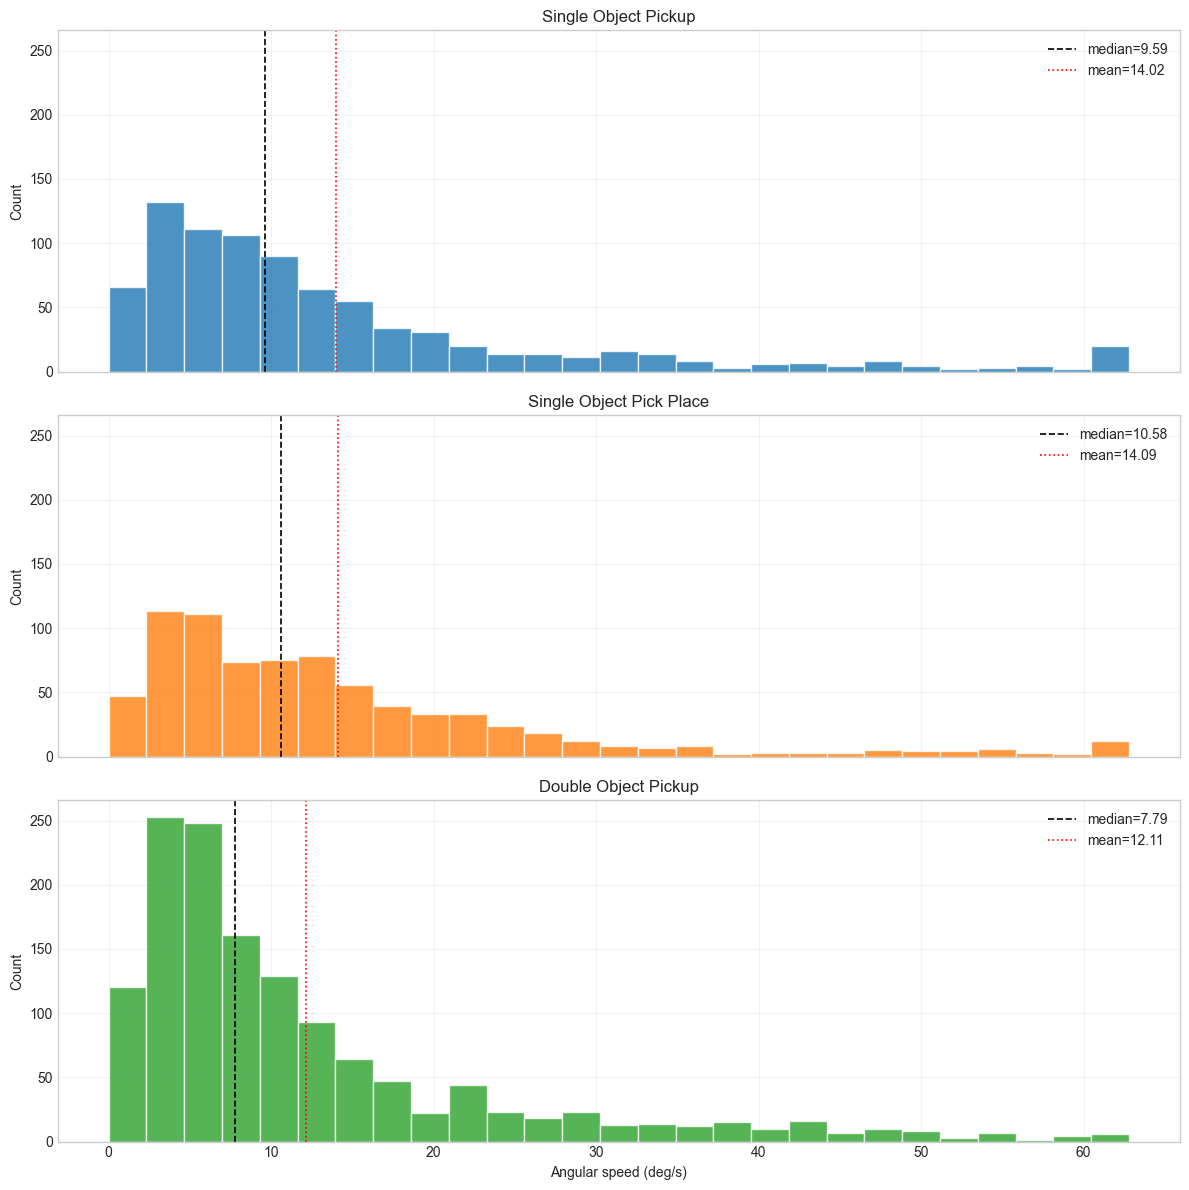

In [31]:
hist_max = float(labeled_df["angular_speed_deg_s"].quantile(0.99))
bins = np.linspace(0.0, hist_max, 28)

fig, axes = plt.subplots(len(TASK_ORDER), 1, figsize=(12, 12), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, task_label in zip(axes, TASK_ORDER):
    task_values = labeled_df.loc[
        labeled_df["task"] == task_label,
        "angular_speed_deg_s",
    ].clip(upper=hist_max)

    ax.hist(
        task_values,
        bins=bins,
        color=TASK_COLORS[task_label],
        alpha=0.8,
        edgecolor="white",
    )
    ax.axvline(task_values.median(), color="black", linestyle="--", linewidth=1.2, label=f"median={task_values.median():.2f}")
    ax.axvline(task_values.mean(), color="red", linestyle=":", linewidth=1.2, label=f"mean={task_values.mean():.2f}")
    ax.set_title(task_label)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Angular speed (deg/s)")
plt.tight_layout()
plt.show()


In [32]:
ordered_segment_df = segment_df[segment_df["task"].isin(MULTI_SEGMENT_TASKS)].copy()

ordered_label_duration_stats = (
    ordered_segment_df.groupby(["task", "ordered_label_id"], sort=False)["duration_sec"]
    .agg(
        segments="count",
        mean="mean",
        median="median",
        p10=lambda series: series.quantile(0.10),
        p90=lambda series: series.quantile(0.90),
        min="min",
        max="max",
    )
    .round(3)
)

display(ordered_label_duration_stats)


segments   mean  median    p10  \
task                     ordered_label_id                                   
Single Object Pick Place 1                       49  0.585   0.533  0.267   
                         2                       48  0.490   0.400  0.267   
Double Object Pickup     1                       73  0.674   0.533  0.267   
                         2                       72  0.586   0.467  0.267   

                                             p90    min    max  
task                     ordered_label_id                       
Single Object Pick Place 1                 1.000  0.133  1.400  
                         2                 0.800  0.200  1.733  
Double Object Pickup     1                 1.173  0.200  2.533  
                         2                 1.060  0.200  1.867

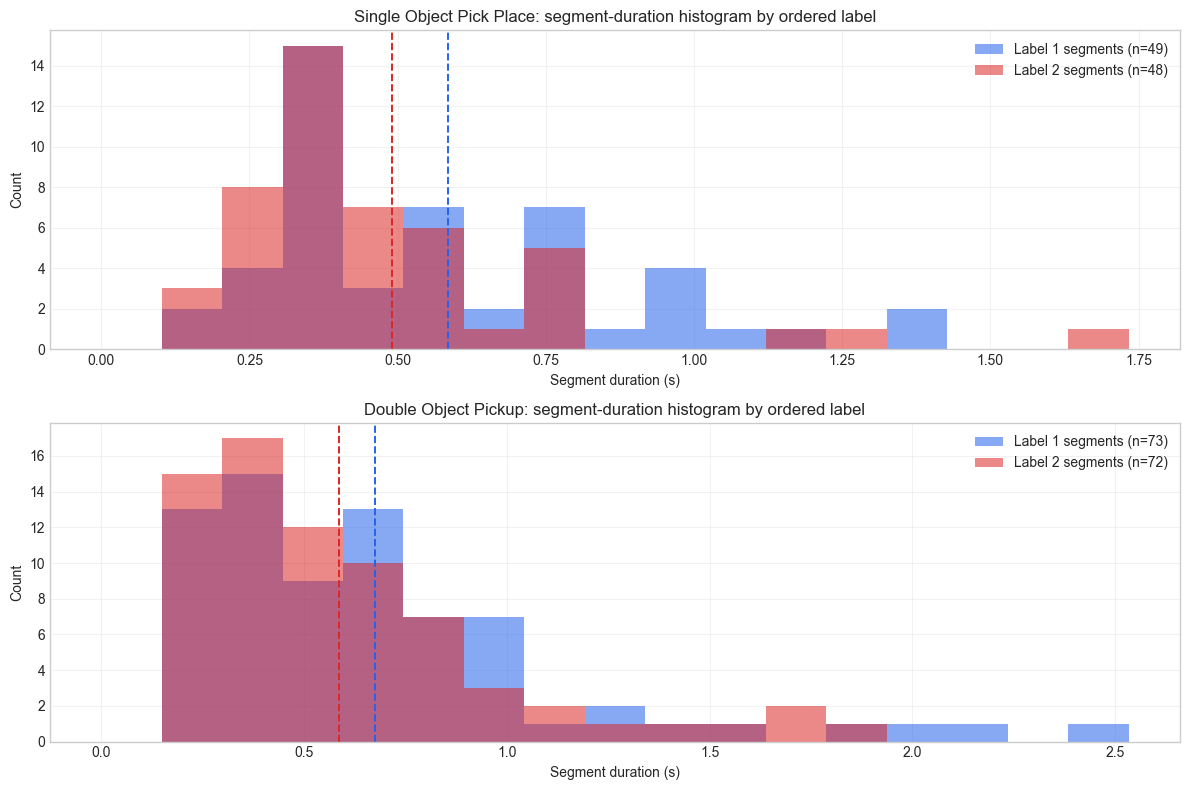

Label 1 = first labeled segment, Label 2 = later labeled segment


In [33]:
fig, axes = plt.subplots(len(MULTI_SEGMENT_TASKS), 1, figsize=(12, 8), sharex=False, sharey=False)
axes = np.atleast_1d(axes)

for ax, task_label in zip(axes, MULTI_SEGMENT_TASKS):
    task_df = ordered_segment_df[ordered_segment_df["task"] == task_label]
    if task_df.empty:
        continue

    duration_max = float(task_df["duration_sec"].max())
    bins = np.linspace(0.0, duration_max, 18)

    for ordered_label_id in [1, 2]:
        label_df = task_df[task_df["ordered_label_id"] == ordered_label_id]
        if label_df.empty:
            continue

        ax.hist(
            label_df["duration_sec"],
            bins=bins,
            alpha=0.55,
            color=ORDERED_LABEL_COLORS[ordered_label_id],
            label=f"Label {ordered_label_id} segments (n={len(label_df)})",
        )
        ax.axvline(
            label_df["duration_sec"].mean(),
            color=ORDERED_LABEL_COLORS[ordered_label_id],
            linestyle="--",
            linewidth=1.4,
        )

    ax.set_title(f"{task_label}: segment-duration histogram by ordered label")
    ax.set_xlabel("Segment duration (s)")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

print("Label 1 = first labeled segment, Label 2 = later labeled segment")


,task,episode,ordered_label_id,start_frame,end_frame,start_sec,end_sec,duration_frames,duration_sec
164,Single Object Pick Place,2f_store_juheon_setup_single_object_pick_place_44,1,50,70,3.333,4.667,21,1.4
165,Single Object Pick Place,2f_store_juheon_setup_single_object_pick_place_44,2,119,124,7.933,8.267,6,0.4


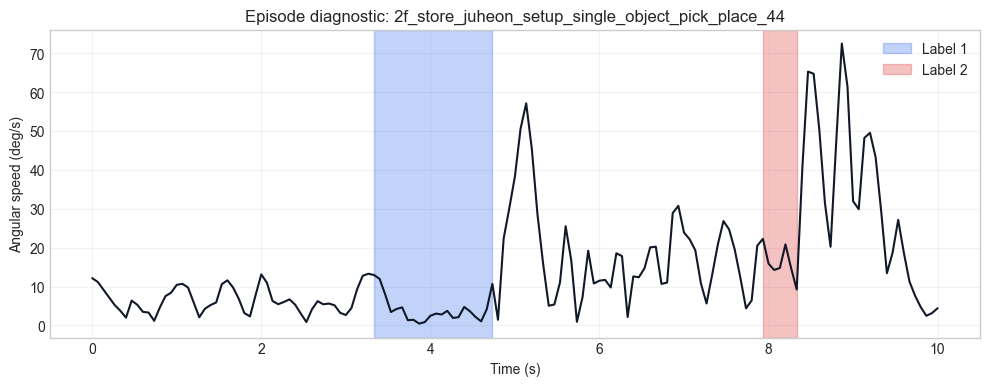

In [34]:
EPISODE_TO_INSPECT = "2f_store_juheon_setup_single_object_pick_place_44"

episode_df = frames_df[frames_df["episode"] == EPISODE_TO_INSPECT].copy()
if episode_df.empty:
    raise ValueError(f"Episode not found: {EPISODE_TO_INSPECT}")

episode_segments = segment_df[segment_df["episode"] == EPISODE_TO_INSPECT].copy()
if episode_segments.empty:
    raise ValueError(f"No labeled segments found for episode: {EPISODE_TO_INSPECT}")

display(episode_segments.round(3))

fps = float(episode_df["fps"].iloc[0])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(episode_df["time_sec"], episode_df["angular_speed_deg_s"], color="#111827", linewidth=1.5)

for _, row in episode_segments.iterrows():
    label_id = int(row["ordered_label_id"])
    ax.axvspan(
        row["start_sec"],
        row["end_sec"] + (1.0 / fps),
        color=ORDERED_LABEL_COLORS.get(label_id, "#9ca3af"),
        alpha=0.28,
        label=f"Label {label_id}",
    )

handles, labels = ax.get_legend_handles_labels()
dedup = dict(zip(labels, handles))
ax.legend(dedup.values(), dedup.keys(), loc="upper right")
ax.set_title(f"Episode diagnostic: {EPISODE_TO_INSPECT}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular speed (deg/s)")
ax.grid(alpha=0.25)
plt.show()
